## 1. SetUp

In [1]:
!pip install torch torchvision scikit-learn matplotlib ultralytics umap

ERROR: Ignored the following versions that require a different python version: 8.0.10 Requires-Python >=3.7,<=3.11; 8.0.11 Requires-Python >=3.7,<=3.11; 8.0.12 Requires-Python >=3.7,<=3.11; 8.0.13 Requires-Python >=3.7,<=3.11; 8.0.14 Requires-Python >=3.7,<=3.11; 8.0.15 Requires-Python >=3.7,<=3.11; 8.0.16 Requires-Python >=3.7,<=3.11; 8.0.17 Requires-Python >=3.7,<=3.11; 8.0.18 Requires-Python >=3.7,<=3.11; 8.0.19 Requires-Python >=3.7,<=3.11; 8.0.20 Requires-Python >=3.7,<=3.11; 8.0.21 Requires-Python >=3.7,<=3.11; 8.0.22 Requires-Python >=3.7,<=3.11; 8.0.23 Requires-Python >=3.7,<=3.11; 8.0.24 Requires-Python >=3.7,<=3.11; 8.0.25 Requires-Python >=3.7,<=3.11; 8.0.26 Requires-Python >=3.7,<=3.11; 8.0.27 Requires-Python >=3.7,<=3.11; 8.0.28 Requires-Python >=3.7,<=3.11; 8.0.29 Requires-Python >=3.7,<=3.11; 8.0.30 Requires-Python >=3.7,<=3.11; 8.0.31 Requires-Python >=3.7,<=3.11; 8.0.32 Requires-Python >=3.7,<=3.11; 8.0.33 Requires-Python >=3.7,<=3.11; 8.0.34 Requires-Python >=3.7,<=3.

In [2]:
!pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2 umap-learn==0.20.0
!pip install ultralytics --no-deps

import ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.8 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11
ERROR: Could not find a version that satisfies the requirement umap-learn==0.20.0 (from versions: 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.2.0, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.3.0, 0.3.1, 0.3.2, 0.3.4, 0.3.5, 0.3.6, 0.3.7,

In [3]:
import os, gc, json, shutil, yaml, warnings, random, math, copy
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE
import umap.umap_ as umap

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from ultralytics import YOLO


warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42); random.seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
print("Device:", device, "| torch", torch.__version__)

E0000 00:00:1769458564.184880      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769458564.254181      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Device: cuda | torch 2.6.0+cu124


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="J1rWUvuwvKwOyLI5ooEK")
project = rf.workspace("sanjana-kazi-supti-ymhu2").project("non-seasonal-vegetable-detection-yms0u")
version = project.version(3)
dataset = version.download("yolov12")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.4 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.3


Extracting Dataset Version Zip to Non-Seasonal-Vegetable-Detection-3 in yolov12:: 100%|██████████| 9606/9606 [00:00<00:00, 9964.97it/s] 


## 2. Assign a detection Catch

In [5]:
def get_detect_module(model_module):
    """Return the Detect head (robust across YOLO versions)."""
    try:
        last = model_module.model[-1]
        if "Detect" in last.__class__.__name__:
            return last
    except Exception:
        pass
    cand = None
    for m in model_module.modules():
        if "Detect" in m.__class__.__name__:
            cand = m
    return cand if cand is not None else list(model_module.modules())[-1]


## 3. Dataset Path

In [6]:
WORK          = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3")  # output directory (can rename)
SSL_W         = WORK / "BYOL_ssl_yolov12_backbone.pth"
WORK.mkdir(parents=True, exist_ok=True)

## 4. Set the Two-view function

In [7]:
class TwoView(Dataset):
    SUPP = ('*.jpg','*.JPG','*.jpeg','*.JPEG','*.png','*.PNG','*.bmp','*.BMP','*.webp','*.WEBP')
    def __init__(self, roots, tfm):
        self.files=[]
        for r in roots:
            pr=Path(r)
            for p in self.SUPP:
                self.files.extend(pr.rglob(p))
        if not self.files: raise RuntimeError(f"No images found under {roots}")
        self.tfm=tfm
    def __len__(self): return len(self.files)
    def __getitem__(self,idx):
        img=Image.open(self.files[idx]).convert("RGB")
        return self.tfm(img), self.tfm(img)

augment = transforms.Compose([
    transforms.RandomResizedCrop(160, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.RandomGrayscale(0.2),
    transforms.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
])

## 5. BYOL Loss Function and Detection hook

In [8]:
def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2*(p*z).sum(dim=1).mean()

class DetectInputHook:
    def __init__(self, detect_module):
        self.handle = detect_module.register_forward_pre_hook(self.hook)
        self.feats = None
    def hook(self, module, inputs):
        # inputs is a tuple with a single item: a list/tuple of FPN maps [P3,P4,P5]
        self.feats = list(inputs[0])  # keep tensors with grad for online
        return None
    def close(self):
        self.handle.remove()

def global_pool_concat(feats):
    pooled = [F.adaptive_avg_pool2d(f, 1).flatten(1) for f in feats]
    return torch.cat(pooled, dim=1)

## 6. YOLOv12s model type backbone, optmizer setup, training loop and save the backbone weight

In [9]:
MODEL = "yolo12s.pt"     # YOLOv12 nano config
SSL_EPOCHS, SSL_BATCH = 50, 64 # EPOCHS and BATCH SIZE
m0 = 0.996

if SSL_W.exists():
    print("BYOL backbone cached – skipping pre-train")
else:
    print("BYOL pre-training (1 epoch, hook-based, YOLOv12) …")

    # full models (we'll read neck features via hook)
    online_full = YOLO(MODEL).model.to(device)
    target_full = YOLO(MODEL).model.to(device)
    target_full.load_state_dict(online_full.state_dict())
    for p in target_full.parameters(): p.requires_grad=False

    # register hooks on Detect heads to capture P3,P4,P5
    online_hook = DetectInputHook(get_detect_module(online_full))
    target_hook = DetectInputHook(get_detect_module(target_full))

    # infer feature dim
    with torch.no_grad():
        dmy = torch.zeros(1,3,160,160,device=device)
        _ = online_full(dmy)                # run forward to populate hook
        feat_dim = global_pool_concat(online_hook.feats).shape[1]
    print("Backbone feature dim:", feat_dim)

    def projector():
        return nn.Sequential(
            nn.Linear(feat_dim,512,bias=False),
            nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512,256,bias=False)
        )
    def predictor():
        return nn.Sequential(
            nn.Linear(256,512,bias=False),
            nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512,256,bias=False)
        )

    proj_o, proj_t = projector().to(device), projector().to(device)
    pred_o         = predictor().to(device)
    proj_t.load_state_dict(proj_o.state_dict())
    for p in proj_t.parameters(): p.requires_grad=False

    # optimize only online_full (backbone+neck) + projector/predictor
    opt = torch.optim.AdamW(
        list(online_full.parameters()) + list(proj_o.parameters()) + list(pred_o.parameters()),
        lr=5e-4, weight_decay=0.05
    )
    scaler = torch.amp.GradScaler(enabled=(device=="cuda"))

    @torch.no_grad()
    def ema_update(src, dst, m):
        for ps, pd in zip(src.parameters(), dst.parameters()):
            pd.data.mul_(m).add_(ps.data, alpha=1-m)

    def momentum_scheduled(step, total_steps, base=m0):
        if total_steps <= 1: return 1.0
        tau = step / (total_steps - 1)
        return 1.0 - (1.0 - base) * (0.5 * (1.0 + math.cos(math.pi * tau)))

    ds = TwoView([WORK/"train"/"images", WORK/"valid"/"images"], augment)
    dl = DataLoader(ds, batch_size=SSL_BATCH, shuffle=True,
                    num_workers=0, pin_memory=False, drop_last=True)

    total_steps = max(1, SSL_EPOCHS * len(dl))
    step = 0
    for ep in range(SSL_EPOCHS):
        online_full.train(); proj_o.train(); pred_o.train()
        running=0.0
        pbar = tqdm(dl, desc=f"BYOL {ep+1}/{SSL_EPOCHS}", leave=False)

        for v1,v2 in pbar:
            v1,v2 = v1.to(device, non_blocking=True), v2.to(device, non_blocking=True)
            m_cur = momentum_scheduled(step, total_steps)

            with torch.autocast(device_type='cuda', enabled=(device=="cuda")):
                # online encodes (features captured by hook)
                _ = online_full(v1)
                h1 = global_pool_concat(online_hook.feats)
                _ = online_full(v2)
                h2 = global_pool_concat(online_hook.feats)

                z1_o = proj_o(h1); z2_o = proj_o(h2)
                p1   = pred_o(z1_o); p2 = pred_o(z2_o)

                # target encodes (EMA, no grad)
                with torch.no_grad():
                    ema_update(online_full, target_full, m_cur)
                    ema_update(proj_o, proj_t, m_cur)
                    _ = target_full(v1)
                    h1_t = global_pool_concat(target_hook.feats)
                    _ = target_full(v2)
                    h2_t = global_pool_concat(target_hook.feats)
                    z1_t = proj_t(h1_t); z2_t = proj_t(h2_t)

                loss = byol_loss(p1, z2_t) + byol_loss(p2, z1_t)

            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
            running += loss.item()
            step += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}", m=f"{m_cur:.4f}")

        print(f"Epoch {ep+1}/{SSL_EPOCHS} BYOL loss={running/len(dl):.4f}")

    # save ONLY backbone+neck weights (exclude Detect head)
    torch.save({k:v for k,v in online_full.state_dict().items()
                if not k.startswith('model.%d' % (len(online_full.model)-1))}, SSL_W)

    online_hook.close(); target_hook.close()
    del online_full, target_full, proj_o, proj_t, pred_o, dl, ds
    gc.collect(); 
    if device=="cuda": torch.cuda.empty_cache()
    print("✓ Saved SSL backbone weights →", SSL_W)

BYOL pre-training (1 epoch, hook-based, YOLOv12) …
Backbone feature dim: 896


BYOL 1/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/50 BYOL loss=1.5851


BYOL 2/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/50 BYOL loss=1.2580


...

Epoch 48/50 BYOL loss=0.6782


BYOL 49/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49/50 BYOL loss=0.6837


BYOL 50/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 50/50 BYOL loss=0.6684
✓ Saved SSL backbone weights → /kaggle/working/Non-Seasonal-Vegetable-Detection-3/BYOL_ssl_yolov12_backbone.pth


## 7. Feature extraction plot (K-NN, PCA, t-SNE, UMAP)

➤ Loading BYOL feature extractor …
➤ Extracting features …


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7d5c4c20f4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error



BYOL k-NN evaluation …
k-NN accuracy (val): 0.6927


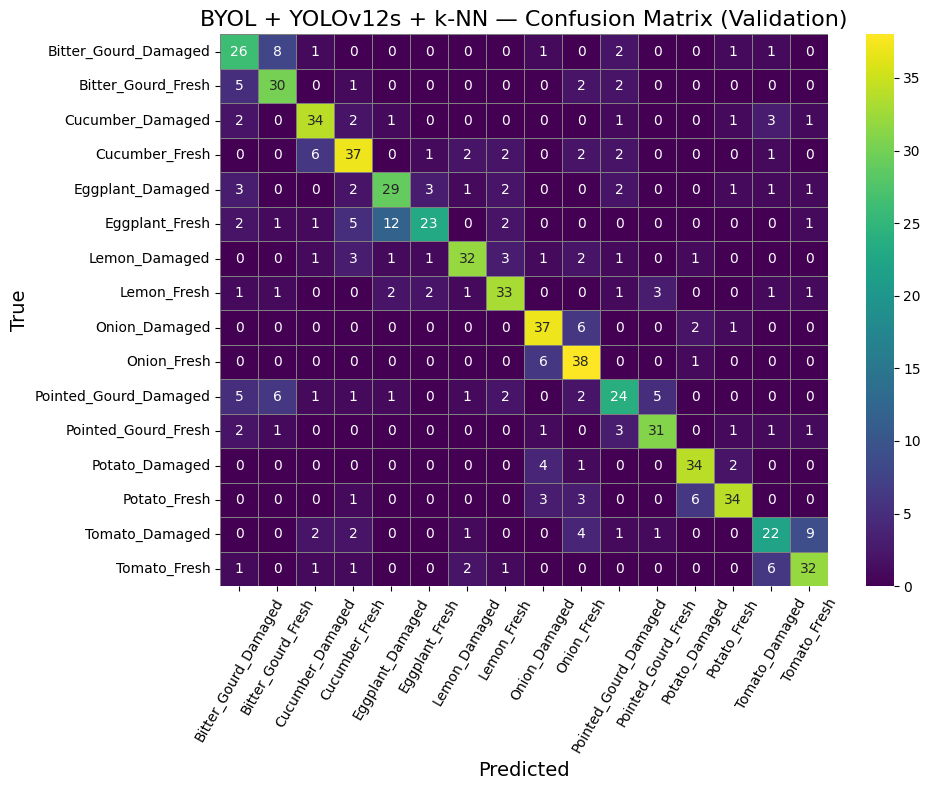

➤ Running PCA …
PCA 2D explained variance: 21.96%


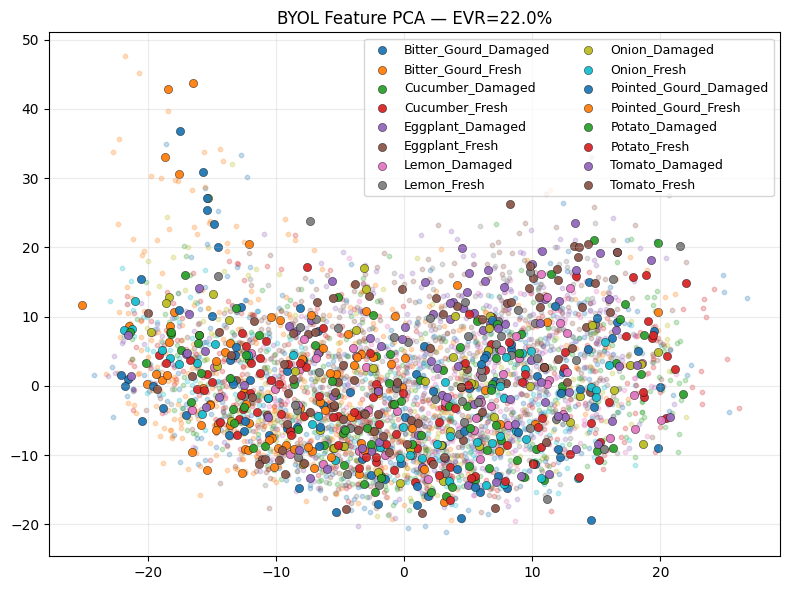

➤ Running t-SNE …


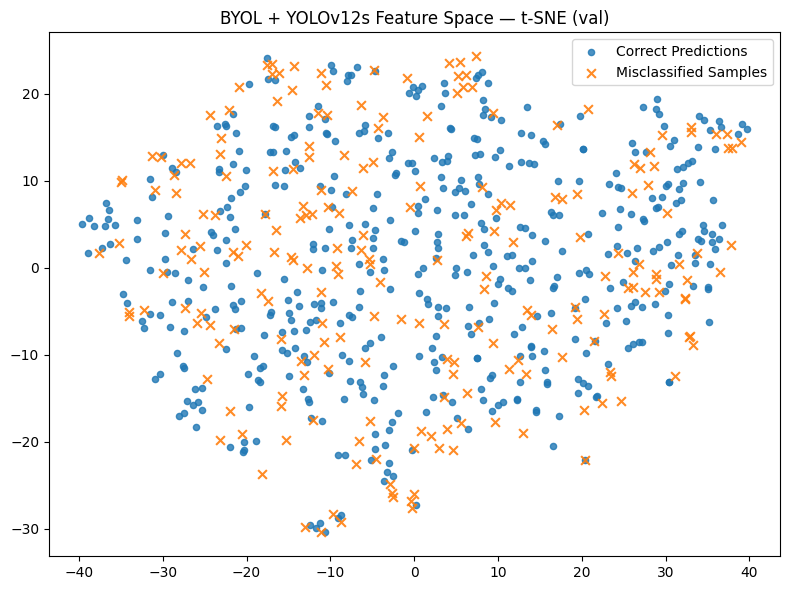

➤ Running UMAP …
⚠️ UMAP failed — skipping UMAP visualization.
Error: check_array() got an unexpected keyword argument 'ensure_all_finite'

✓ All visualizations saved in: /kaggle/working/Non-Seasonal-Vegetable-Detection-3/plots


In [10]:
import os, gc, torch, umap, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from ultralytics import YOLO

# -----------------------------------------
# CONFIG
# -----------------------------------------
PLOTS = WORK / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

class_names = [
    "Bitter_Gourd_Damaged",
    "Bitter_Gourd_Fresh",
    "Cucumber_Damaged",
    "Cucumber_Fresh",
    "Eggplant_Damaged",
    "Eggplant_Fresh",
    "Lemon_Damaged",
    "Lemon_Fresh",
    "Onion_Damaged",
    "Onion_Fresh",
    "Pointed_Gourd_Damaged",
    "Pointed_Gourd_Fresh",
    "Potato_Damaged",
    "Potato_Fresh",
    "Tomato_Damaged",
    "Tomato_Fresh"
]

# -----------------------------------------
# HELPERS
# -----------------------------------------
def imread_rgb(path: Path):
    return Image.open(path).convert("RGB")

def yolo_label_for_image(label_file: Path):
    if not label_file.exists():
        return None
    ids=[]
    with open(label_file) as f:
        for line in f:
            parts=line.strip().split()
            if parts:
                try: ids.append(int(parts[0]))
                except: pass
    return max(ids, key=ids.count) if ids else None

def list_images_and_labels(split_dir: Path):
    xs, ys = [], []
    images = sorted((split_dir/"images").glob("*.*"))
    for img_path in images:
        lb_path = (split_dir/"labels"/(img_path.stem + ".txt"))
        lab = yolo_label_for_image(lb_path)
        if lab is None:
            continue
        xs.append(img_path); ys.append(lab)
    return xs, np.array(ys, dtype=np.int64)

def get_detect_module(model_module):
    try:
        last = model_module.model[-1]
        if "Detect" in last.__class__.__name__:
            return last
    except Exception:
        pass
    cand = None
    for m in model_module.modules():
        if "Detect" in m.__class__.__name__:
            cand = m
    return cand if cand is not None else list(model_module.modules())[-1]

class DetectInputHook:
    def __init__(self, detect_module):
        self.handle = detect_module.register_forward_pre_hook(self.hook)
        self.feats = None
    def hook(self, module, inputs):
        self.feats = list(inputs[0])    # [P3,P4,P5]
    def close(self): self.handle.remove()

def global_pool_concat(feats):
    pooled = [F.adaptive_avg_pool2d(f, 1).flatten(1) for f in feats]
    return torch.cat(pooled, dim=1)

# -----------------------------------------
# DATA
# -----------------------------------------
train_X, train_y = list_images_and_labels(WORK/"train")
val_X,   val_y   = list_images_and_labels(WORK/"valid")
assert len(train_X) and len(val_X), "No labeled images found."

# -----------------------------------------
# FEATURE EXTRACTION
# -----------------------------------------
print("➤ Loading BYOL feature extractor …")
feat_model = YOLO("yolo12s.pt").model.to(device)
_ = feat_model.load_state_dict(torch.load(SSL_W, map_location="cpu"), strict=False)

feat_hook = DetectInputHook(get_detect_module(feat_model))
feat_model.eval()

base_tfm = transforms.Compose([transforms.Resize((160,160)), transforms.ToTensor()])

class ImgDataset(Dataset):
    def __init__(self, paths, tfm): self.paths=paths; self.tfm=tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self,i): return self.tfm(imread_rgb(self.paths[i]))

def extract_feats(paths, bs=64, desc="Extract"):
    ds  = ImgDataset(paths, base_tfm)
    dl  = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=False)
    feats=[]
    for xb in tqdm(dl, total=len(dl), desc=desc, leave=False):
        xb = xb.to(device, non_blocking=True)
        with torch.no_grad():
            _ = feat_model(xb)
            h  = global_pool_concat(feat_hook.feats)
        feats.append(h.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,1))

print("➤ Extracting features …")
train_F = extract_feats(train_X, bs=64, desc="Extract train")
val_F   = extract_feats(val_X,   bs=64, desc="Extract val")

feat_hook.close()
del feat_model
gc.collect()
if device=="cuda":
    torch.cuda.empty_cache()

# -----------------------------------------
# k-NN CLASSIFIER
# -----------------------------------------
print("\nBYOL k-NN evaluation …")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(train_F, train_y)

val_pred = knn.predict(val_F)
acc = accuracy_score(val_y, val_pred)
print(f"k-NN accuracy (val): {acc:.4f}")

# -----------------------------------------
# CONFUSION MATRIX — BEAUTIFUL VERSION
# -----------------------------------------
cm = confusion_matrix(val_y, val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="gray"
)
plt.title("BYOL + YOLOv12s + k-NN — Confusion Matrix (Validation)", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS/"knn_confusion_matrix.png", dpi=200)
plt.show()

# -----------------------------------------
# STANDARDIZE
# -----------------------------------------
scaler = StandardScaler()
train_Fs = scaler.fit_transform(train_F)
val_Fs   = scaler.transform(val_F)

# -----------------------------------------
# PCA VISUALIZATION
# -----------------------------------------
print("➤ Running PCA …")
pca = PCA(n_components=2, random_state=42)
train_P = pca.fit_transform(train_Fs)
val_P   = pca.transform(val_Fs)
evr = pca.explained_variance_ratio_.sum()
print(f"PCA 2D explained variance: {evr*100:.2f}%")

plt.figure(figsize=(8, 6))
cmap = plt.get_cmap("tab10")

classes = np.unique(np.concatenate([train_y, val_y]))

for c in classes:
    idx = np.where(train_y == c)[0]
    if len(idx):
        plt.scatter(train_P[idx,0], train_P[idx,1], s=10, alpha=0.25, color=cmap(c%10))

for c in classes:
    idx = np.where(val_y == c)[0]
    if len(idx):
        plt.scatter(
            val_P[idx,0], val_P[idx,1],
            s=35, alpha=0.95,
            edgecolors="k", linewidths=0.3,
            color=cmap(c%10),
            label=class_names[c]
        )

plt.title(f"BYOL Feature PCA — EVR={evr*100:.1f}%")
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(PLOTS/"pca_train_val.png", dpi=200)
plt.show()

# -----------------------------------------
# t-SNE
# -----------------------------------------
if len(val_F) > 10:
    print("➤ Running t-SNE …")
    perplex = min(30, max(5, len(val_F)//10))
    tsne = TSNE(n_components=2, init="pca", learning_rate="auto",
                perplexity=perplex, n_iter=1000, random_state=42)

    Z_tsne = tsne.fit_transform(val_Fs)
    mistakes = (val_pred != val_y)

    plt.figure(figsize=(8, 6))
    plt.scatter(Z_tsne[~mistakes,0], Z_tsne[~mistakes,1], s=20, label="Correct Predictions", alpha=0.8)
    plt.scatter(Z_tsne[mistakes,0],   Z_tsne[mistakes,1],   s=40, marker="x", label="Misclassified Samples", alpha=0.9)

    plt.title("BYOL + YOLOv12s Feature Space — t-SNE (val)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS/"tsne_val.png", dpi=200)
    plt.show()

# -----------------------------------------
# UMAP WITH ERROR HANDLING
# -----------------------------------------
print("➤ Running UMAP …")

try:
    umap_model = umap.UMAP(n_components=2, random_state=42)
    Z_umap = umap_model.fit_transform(val_Fs)

    plt.figure(figsize=(6,5))
    for c in classes:
        idx = np.where(val_y == c)[0]
        plt.scatter(Z_umap[idx,0], Z_umap[idx,1], s=28, alpha=0.9, label=class_names[c])

    plt.title("BYOL + YOLOv12s Feature Space — UMAP (val)")
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(PLOTS/"umap_val.png", dpi=160)
    plt.show()

except Exception as e:
    print("⚠️ UMAP failed — skipping UMAP visualization.")
    print("Error:", e)

print("\n✓ All visualizations saved in:", PLOTS)


## 8. Load the backbone model and Fine-Tune with YOLOv12s Type detection Model

In [11]:
!pip install --quiet --upgrade numpy==1.25.2 scipy==1.10.1 scikit-learn==1.3.2 umap-learn==0.20.0
!pip install ultralytics --no-deps

import ultralytics

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11
ERROR: Could not find a version that satisfies the requirement umap-learn==0.20.0 (from versions: 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.2.0, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.3.0, 0.3.1, 0.3.2, 0.3.4, 0.3.5, 0.3.6, 0.3.7, 0.3.8, 0.3.9, 0.3.10, 0.4.0rc1, 0.4.0rc2, 0.4.0rc3, 0.4.0, 0.4.1, 0.4.2, 0.4.3,

In [12]:
print("\n Fine-tuning YOLOv11-s (1 epoch) …")
det = YOLO(MODEL)  # nano to match SSL shapes
# load into all-but-Detect
sd = torch.load(SSL_W, map_location="cpu")
det.model.load_state_dict(sd, strict=False)

det.train(
    data=str("/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml"),
    epochs=50,                # ← set to 50 epoch
    imgsz=640,
    batch=12,
    project=str(WORK),
    save = True,
    name="byol_yolo12s",
    device=0 if device=="cuda" else None,
    verbose=True
)



 Fine-tuning YOLOv11-s (1 epoch) …
Ultralytics 8.4.7 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=byol_yolo12s, nbs=64, nms=False, opset=None, optimize=False, optim

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d5a6810a390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

## 9. Loss Curve Visualization


Loaded columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7'] 

Plotting epochs: 2 → 49



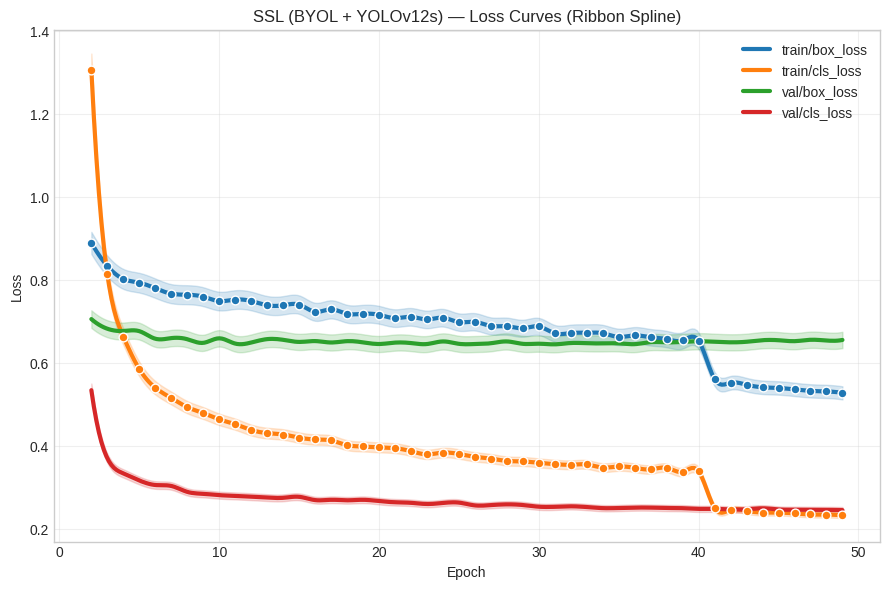

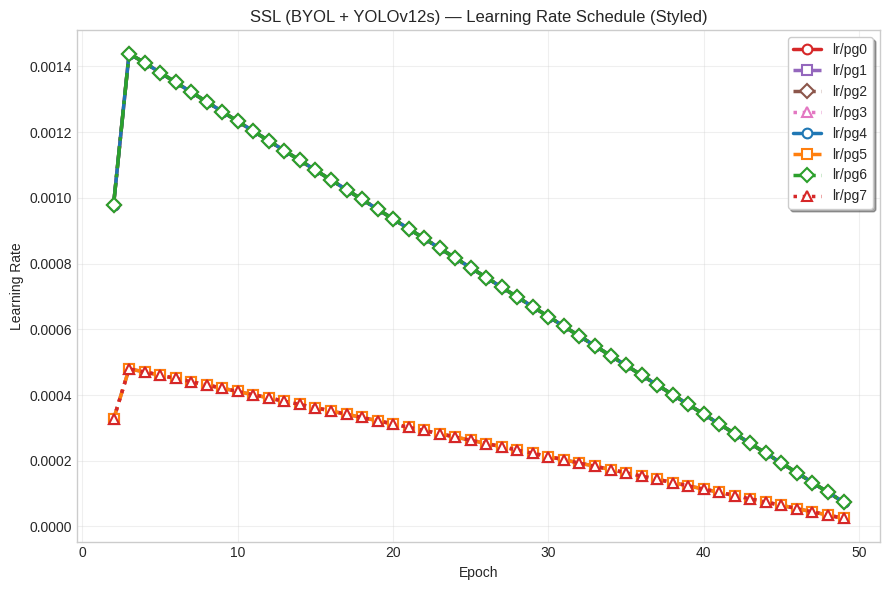

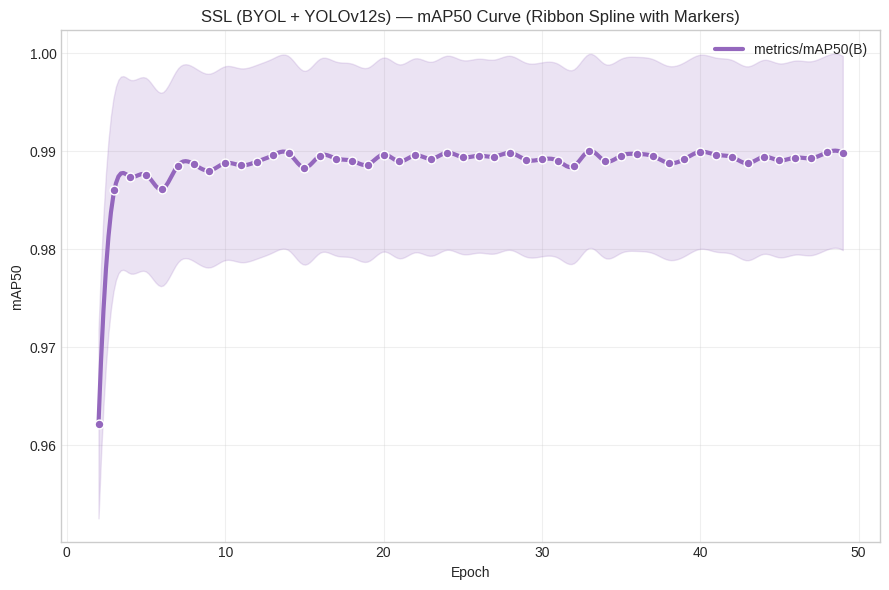

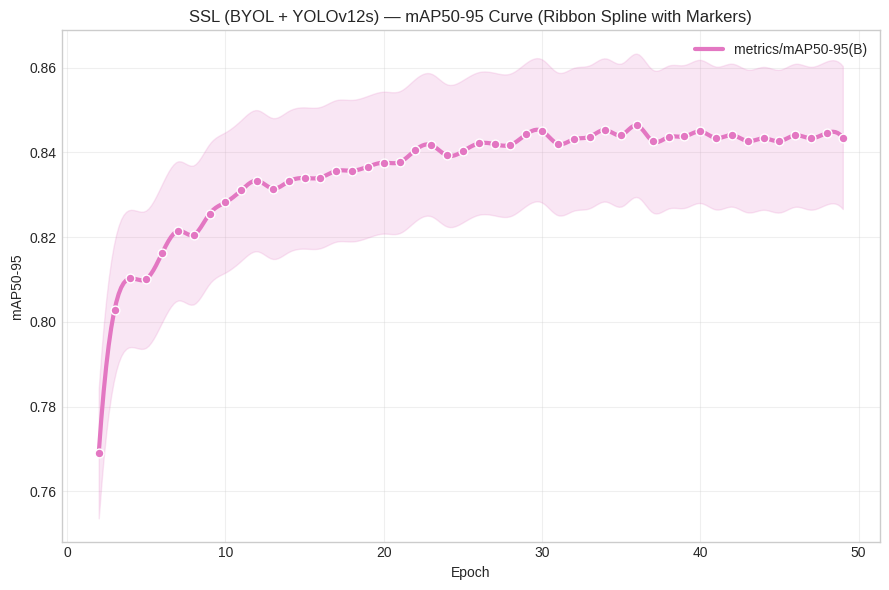

In [13]:
# ============================================================
# SSL (BYOL + YOLOv12s) — Ribbon Spline Curves (Except Learning Rate)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.interpolate import make_interp_spline

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
results_path = Path("/kaggle/working/Non-Seasonal-Vegetable-Detection-3/byol_yolo12s/results.csv")
df = pd.read_csv(results_path)

print("\nLoaded columns:", df.columns.tolist(), "\n")

# Remove first and last epoch (to avoid dips)
df_plot = df.iloc[1:-1].reset_index(drop=True)
print(f"Plotting epochs: {df_plot['epoch'].min()} → {df_plot['epoch'].max()}\n")


# ------------------------------------------------------------
# Updated Color Palette (Vibrant & Distinct)
# ------------------------------------------------------------
palette = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
]


# ------------------------------------------------------------
# Helper: Cubic Spline + Ribbon Fill (ONLY for Loss & mAP)
# ------------------------------------------------------------
def ribbon_spline(ax, x, y, color, label=None):
    x = np.array(x)
    y = np.array(y)

    # smooth spline
    xs = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    ys = spline(xs)

    # ribbon (soft thickness)
    ax.fill_between(xs, ys * 0.97, ys * 1.03, color=color, alpha=0.18)

    # main curve
    ax.plot(xs, ys, color=color, linewidth=3, label=label)

    return xs, ys


# ============================================================
# LOSS PLOT — Ribbon Spline Curves (Training Loss with 'o' markers)
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

loss_keys = ["train/box_loss", "train/cls_loss", "val/box_loss", "val/cls_loss"]

for i, col in enumerate(loss_keys):
    if col not in df_plot.columns:
        continue

    color = palette[i % len(palette)]

    # Only add 'o' markers for training loss curves
    if "train" in col:
        x = np.array(df_plot["epoch"])
        y = np.array(df_plot[col])
        xs = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        ys = spline(xs)

        ax.fill_between(xs, ys * 0.97, ys * 1.03, color=color, alpha=0.18)
        ax.plot(xs, ys, color=color, linewidth=3, label=col)
        ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)
    else:
        ribbon_spline(ax, df_plot["epoch"], df_plot[col], color, col)

ax.set_title("SSL (BYOL + YOLOv12s) — Loss Curves (Ribbon Spline)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# LEARNING RATE PLOT — DISTINCT STYLES
# ============================================================
lr_cols = [c for c in df_plot.columns if c.startswith("lr/")]

if lr_cols:
    fig, ax = plt.subplots(figsize=(9, 6))

    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "D", "^"]

    for i, col in enumerate(lr_cols):
        color = palette[(i + 3) % len(palette)]
        style = line_styles[i % len(line_styles)]
        marker = markers[i % len(markers)]

        ax.plot(
            df_plot["epoch"],
            df_plot[col],
            color=color,
            linestyle=style,
            linewidth=2.5,
            marker=marker,
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.5,
            label=col
        )

    ax.set_title("SSL (BYOL + YOLOv12s) — Learning Rate Schedule (Styled)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.legend(frameon=True, shadow=True)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No learning rate columns found.")


# ============================================================
# mAP50 — Ribbon Spline (with 'o' markers)
# ============================================================
map50_col = "metrics/mAP50(B)"

if map50_col in df_plot.columns:
    fig, ax = plt.subplots(figsize=(9, 6))

    color = palette[4]  # purple

    x = np.array(df_plot["epoch"])
    y = np.array(df_plot[map50_col])
    xs = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    ys = spline(xs)

    ax.fill_between(xs, ys * 0.99, ys * 1.01, color=color, alpha=0.18)
    ax.plot(xs, ys, color=color, linewidth=3, label=map50_col)
    ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)

    ax.set_title("SSL (BYOL + YOLOv12s) — mAP50 Curve (Ribbon Spline with Markers)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP50")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP50 not found.")


# ============================================================
# mAP50-95 — Ribbon Spline (with 'o' markers)
# ============================================================
map5095_col = "metrics/mAP50-95(B)"

if map5095_col in df_plot.columns:
    fig, ax = plt.subplots(figsize=(9, 6))

    color = palette[6]  # pink

    x = np.array(df_plot["epoch"])
    y = np.array(df_plot[map5095_col])
    xs = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=3)
    ys = spline(xs)

    ax.fill_between(xs, ys * 0.98, ys * 1.02, color=color, alpha=0.18)
    ax.plot(xs, ys, color=color, linewidth=3, label=map5095_col)
    ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)

    ax.set_title("SSL (BYOL + YOLOv12s) — mAP50-95 Curve (Ribbon Spline with Markers)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP50-95")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP50-95 not found.")


## 10. Evaluation and Visualization


 Evaluating …
Ultralytics 8.4.7 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 159 layers, 9,237,072 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 714.4±297.7 MB/s, size: 29.9 KB)
val: Scanning /kaggle/working/Non-Seasonal-Vegetable-Detection-3/valid/labels.cache... 717 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 717/717 273.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 180/180 11.5it/s 15.7s
                   all        717       3615      0.985      0.989       0.99      0.846
  Bitter_Gourd_Damaged         49        222       0.99      0.982      0.993      0.879
    Bitter_Gourd_Fresh         52        161      0.971      0.994      0.995      0.906
      Cucumber_Damaged         63        254      0.996      0.994      0.995      0.828
        Cucumber_Fresh         64        244      0.995          1      0.994      0.846
      

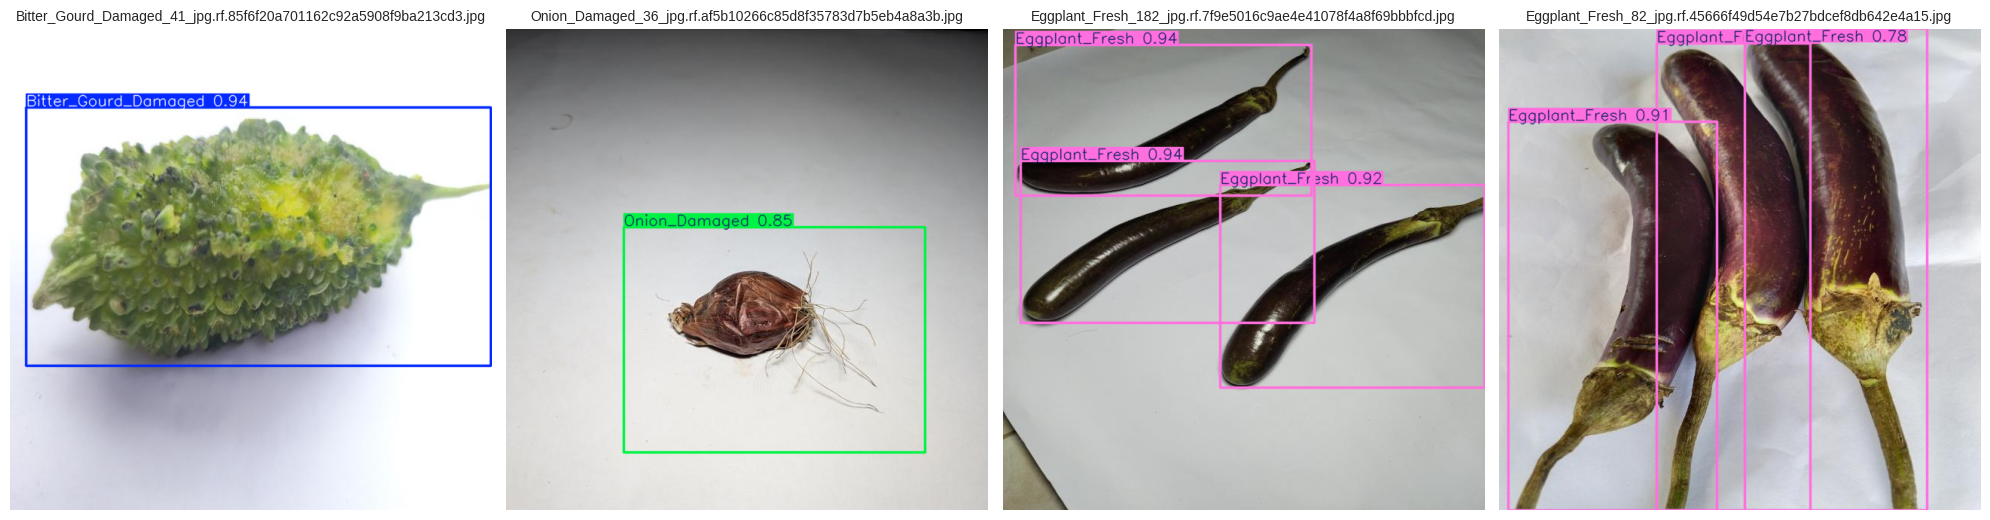

In [14]:

print("\n Evaluating …")
best_pt = WORK / "byol_yolo12s"/"weights"/"best.pt"
model   = YOLO(str(best_pt))
results = model.val(data=str("/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml"), imgsz=640, batch=4, device=0 if device=="cuda" else None)

try:
    mp,mr,map50,map5095 = results.mean_results()
    print("\nValidation metrics")
    print(f"Precision (mP)   : {mp:.4f}")
    print(f"Recall (mR)      : {mr:.4f}")
    print(f"mAP@0.50         : {map50:.4f}")
    print(f"mAP@0.50:0.95    : {map5095:.4f}")
except Exception:
    print("Ultralytics API changed; raw results follows:")
    print(results)

import random

# pick from test or valid images
cands = list((WORK/"test"/"images").glob("*.*")) or list((WORK/"valid"/"images").glob("*.*"))

if cands:
    imgs = random.sample(cands, min(4, len(cands)))  # pick up to 4 random images
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes = axes.flatten()

    for ax, img_path in zip(axes, imgs):
        print("Visualising:", img_path.name)
        pred = model.predict(
            source=str(img_path),
            imgsz=640,
            conf=0.25,
            device=0 if device == "cuda" else None,
            verbose=False
        )[0]
        ax.imshow(pred.plot()[:,:,::-1])
        ax.axis("off")
        ax.set_title(img_path.name, fontsize=10)

    # hide unused axes if <4 images
    for ax in axes[len(imgs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("No images found for visualization.")

